# 📏 Sessão 04 — Inventário Florestal e Amostragem

> **Objetivo:** estabelecer a base estatística do inventário florestal por meio dos processos de Amostragem Aleatória Simples (AAS) e Amostragem Estratificada (AE), demonstrando quantitativamente o **ganho de precisão** obtido pela estratificação quando os estratos são heterogêneos entre si e homogêneos internamente.

---

## 📑 Sumário

1. [Fundamentação Teórica](#1-fundamentação-teórica)
2. [Setup e Dados](#2-setup-e-dados)
3. [Cálculo do Volume por Parcela](#3-cálculo-do-volume-por-parcela)
4. [Amostragem Aleatória Simples (AAS)](#4-amostragem-aleatória-simples-aas)
5. [Amostragem Estratificada (AE)](#5-amostragem-estratificada-ae)
6. [Comparação AAS vs. AE](#6-comparação-aas-vs-ae)
7. [Suficiência Amostral](#7-suficiência-amostral)
8. [Síntese](#8-síntese)

## 1. Fundamentação Teórica

O **inventário florestal** estima parâmetros populacionais (volume por hectare, área basal, número de árvores) a partir de uma amostra de unidades (parcelas). Os dois processos amostrais básicos são:

### Amostragem Aleatória Simples (AAS)

Cada parcela tem igual probabilidade de seleção. A média amostral $\bar{x}$ estima a média populacional, e sua variância é:

$$\hat{V}(\bar{x}) = \frac{s^2}{n} \cdot \frac{N - n}{N}$$

onde $s^2$ é a variância amostral, $n$ o tamanho da amostra e $\frac{N-n}{N}$ é o **fator de correção para populações finitas (FPC)**.

### Amostragem Estratificada (AE)

A população é dividida em $L$ estratos homogêneos (ex.: classes de sítio), e dentro de cada estrato aplica-se AAS. A média estratificada é a soma ponderada:

$$\bar{x}_{st} = \sum_{h=1}^{L} W_h \bar{x}_h \qquad W_h = \frac{N_h}{N}$$

E sua variância:

$$\hat{V}(\bar{x}_{st}) = \sum_{h=1}^{L} W_h^2 \frac{s_h^2}{n_h}$$

A AE é **mais precisa** que a AAS quando a variável de estratificação está correlacionada com a variável de interesse (Cochran, 1977).

## 2. Setup e Dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from forestpy.data.loaders import load_pef_vinhedo
from forestpy.inventario.amostragem import aas, estratificada, tamanho_amostra
from forestpy.utils import set_seed, get_logger
from forestpy.viz.style import apply_forest_style

set_seed(42)
apply_forest_style()
log = get_logger('sessao_04')

df = load_pef_vinhedo(synthetic_fallback=True, n_synthetic=500)
log.info(f'Dataset: {df.shape[0]} árvores em {df["parcela"].nunique()} parcelas')

[16:35:35] INFO     Dataset: 500 árvores em 30 parcelas

## 3. Cálculo do Volume por Parcela

A unidade amostral do inventário é a **parcela**, não a árvore individual. Agregamos o volume das árvores em cada parcela e atribuímos a classe de sítio dominante (moda) como variável de estratificação.

In [2]:
# Agrega volume total e classe dominante por parcela
parcelas = df.groupby('parcela').agg(
    volume_total=('volume', 'sum'),
    n_arvores=('arvore', 'count'),
    classe=('classe', lambda x: x.mode().iloc[0]),  # moda
).reset_index()

# Em inventário, expressa-se volume por hectare. Assumindo parcelas de 500 m² (0,05 ha):
AREA_PARCELA_HA = 0.05
parcelas['volume_ha'] = parcelas['volume_total'] / AREA_PARCELA_HA

parcelas

,parcela,volume_total,n_arvores,classe,volume_ha
0,1,2.3820,17,III,47.640
1,2,3.2964,11,II,65.928
2,3,2.9914,16,III,59.828
3,4,9.9247,23,II,198.494
4,5,19.1466,24,I,382.932
5,6,4.6595,17,III,93.190
6,7,1.8968,8,III,37.936
7,8,3.2278,15,III,64.556
8,9,28.7550,23,I,575.100
9,10,7.4189,23,II,148.378


In [3]:
# Estatísticas descritivas do volume/ha
print('Distribuição de volume por hectare (m³/ha):')
print(parcelas['volume_ha'].describe().round(2))

Distribuição de volume por hectare (m³/ha):
count     30.00
mean     149.94
std      130.64
min       19.68
25%       66.07
50%      104.79
75%      186.13
max      575.10
Name: volume_ha, dtype: float64


## 4. Amostragem Aleatória Simples (AAS)

Estima a média populacional do volume/ha tratando todas as parcelas como provenientes de uma única população.

In [4]:
res_aas = aas(
    parcelas['volume_ha'],
    confidence_level=0.95,
)
print(res_aas.summary())

Resultado: AAS
──────────────────────────────────────────────────
  Tamanho da amostra (n)     : 30
  Média estimada             : 149.9393
  Variância da média         : 568.886049
  Erro-padrão da média       : 23.8513
  IC 95%                     : [101.1578, 198.7207]
  Erro de amostragem (%)     : 32.53%


## 5. Amostragem Estratificada (AE)

Agora explora-se a estrutura: as classes de sítio são naturalmente homogêneas internamente e diferentes entre si.

In [5]:
res_ae = estratificada(
    parcelas,
    valor_col='volume_ha',
    estrato_col='classe',
    confidence_level=0.95,
)
print(res_ae.summary())

Resultado: AE
──────────────────────────────────────────────────
  Tamanho da amostra (n)     : 30
  Média estimada             : 149.9393
  Variância da média         : 211.669208
  Erro-padrão da média       : 14.5489
  IC 95%                     : [120.0875, 179.7911]
  Erro de amostragem (%)     : 19.91%


In [6]:
# Médias por estrato
estatisticas_estrato = parcelas.groupby('classe').agg(
    n=('volume_ha', 'count'),
    media=('volume_ha', 'mean'),
    cv=('volume_ha', lambda x: x.std() / x.mean() * 100),
).round(2)
estatisticas_estrato.columns = ['n', 'média (m³/ha)', 'CV (%)']
estatisticas_estrato

,n,média (m³/ha),CV (%)
classe,,,
I,7,332.15,44.05
II,11,129.82,40.48
III,12,62.09,47.15


## 6. Comparação AAS vs. AE

In [7]:
# Tabela comparativa
comparativo = pd.DataFrame({
    'Método': ['AAS', 'AE'],
    'Média (m³/ha)': [res_aas.mean, res_ae.mean],
    'Erro-padrão': [res_aas.std_error, res_ae.std_error],
    'Erro amostral (%)': [res_aas.sampling_error_pct, res_ae.sampling_error_pct],
    'IC inferior': [res_aas.ci_lower, res_ae.ci_lower],
    'IC superior': [res_aas.ci_upper, res_ae.ci_upper],
}).round(4)

comparativo.to_csv('../reports/tables/04_comparativo_amostragem.csv', index=False)
comparativo

,Método,Média (m³/ha),Erro-padrão,Erro amostral (%),IC inferior,IC superior
0,AAS,149.9393,23.8513,32.5341,101.1578,198.7207
1,AE,149.9393,14.5489,19.9093,120.0875,179.7911


In [8]:
# Quantificação do ganho de precisão
ganho_pct = (1 - res_ae.std_error / res_aas.std_error) * 100
amplitude_aas = res_aas.ci_upper - res_aas.ci_lower
amplitude_ae = res_ae.ci_upper - res_ae.ci_lower

log.info(f'Redução do erro-padrão (AE vs. AAS): {ganho_pct:.1f}%')
log.info(f'Amplitude do IC 95% — AAS: {amplitude_aas:.2f} m³/ha')
log.info(f'Amplitude do IC 95% — AE : {amplitude_ae:.2f} m³/ha')

[16:36:18] INFO     Redução do erro-padrão (AE vs. AAS): 39.0%

           INFO     Amplitude do IC 95% — AAS: 97.56 m³/ha

           INFO     Amplitude do IC 95% — AE : 59.70 m³/ha

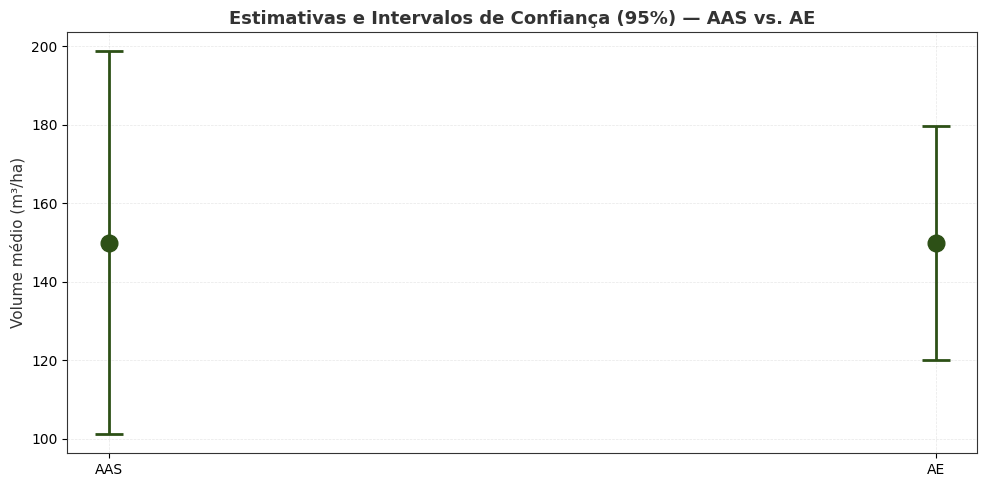

In [9]:
# Visualização: ICs e amplitude do erro
fig, ax = plt.subplots(figsize=(10, 5))

metodos = ['AAS', 'AE']
medias = [res_aas.mean, res_ae.mean]
erros_inf = [res_aas.mean - res_aas.ci_lower, res_ae.mean - res_ae.ci_lower]
erros_sup = [res_aas.ci_upper - res_aas.mean, res_ae.ci_upper - res_ae.mean]

ax.errorbar(
    metodos, medias, yerr=[erros_inf, erros_sup],
    fmt='o', markersize=12, capsize=10, capthick=2, linewidth=2,
    color='#2d5016',
)
ax.set_ylabel('Volume médio (m³/ha)')
ax.set_title('Estimativas e Intervalos de Confiança (95%) — AAS vs. AE',
             fontweight='bold')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('../reports/figures/04_ic_aas_vs_ae.png')
plt.show()

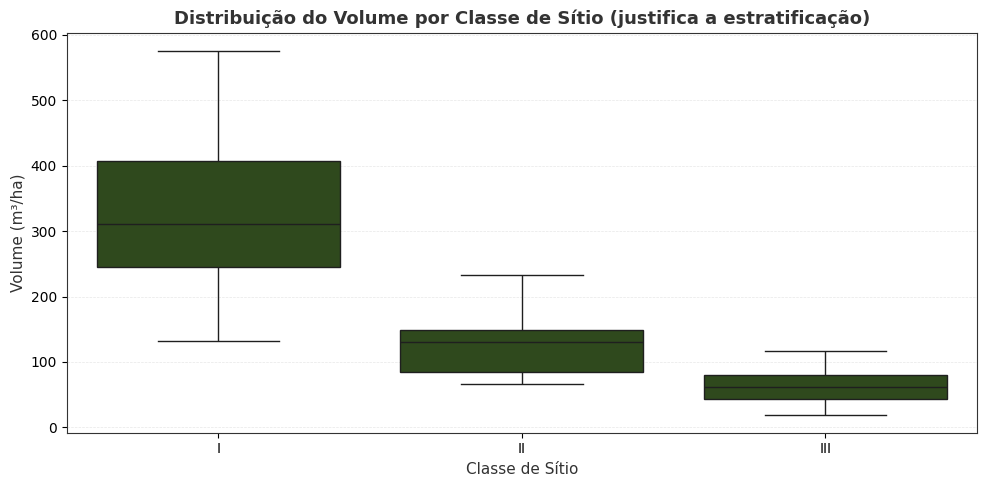

In [10]:
# Boxplot do volume/ha por classe (visualiza a heterogeneidade entre estratos)
fig2, ax2 = plt.subplots(figsize=(10, 5))
sns.boxplot(data=parcelas, x='classe', y='volume_ha', ax=ax2, order=['I', 'II', 'III'])
ax2.set_xlabel('Classe de Sítio')
ax2.set_ylabel('Volume (m³/ha)')
ax2.set_title('Distribuição do Volume por Classe de Sítio (justifica a estratificação)',
              fontweight='bold')
fig2.tight_layout()
fig2.savefig('../reports/figures/04_volume_por_classe.png')
plt.show()

## 7. Suficiência Amostral

Determina o número mínimo de parcelas para atingir um erro de amostragem admissível. A fórmula básica de Cochran (1977) é:

$$n = \frac{t^2 \cdot CV^2}{E^2}$$

onde $CV$ é o coeficiente de variação observado e $E$ é o erro percentual admitido.

In [11]:
cv_obs = parcelas['volume_ha'].std() / parcelas['volume_ha'].mean() * 100
log.info(f'Coeficiente de variação observado: CV = {cv_obs:.1f}%')

# Suficiência para diferentes níveis de erro admissível
erros = [5, 10, 15, 20]
n_necessarios = [tamanho_amostra(cv_obs, e, 0.95) for e in erros]

suficiencia = pd.DataFrame({
    'Erro admissível (%)': erros,
    'Tamanho mínimo (n)': n_necessarios,
})
suficiencia

[16:36:43] INFO     Coeficiente de variação observado: CV = 87.1%

,Erro admissível (%),Tamanho mínimo (n)
0,5,1167
1,10,292
2,15,130
3,20,73


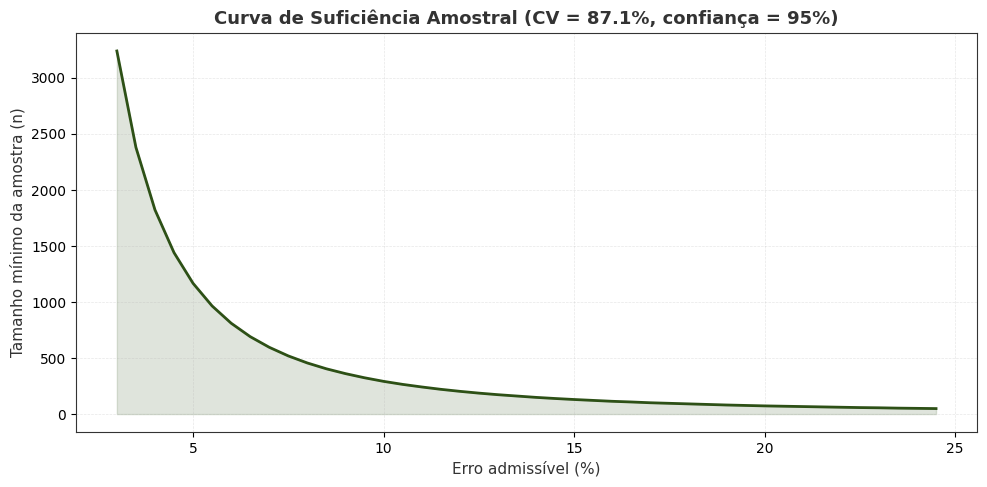

In [12]:
# Curva de suficiência amostral
fig3, ax3 = plt.subplots(figsize=(10, 5))

erros_grade = np.arange(3, 25, 0.5)
n_grade = [tamanho_amostra(cv_obs, e, 0.95) for e in erros_grade]

ax3.plot(erros_grade, n_grade, lw=2, color='#2d5016')
ax3.fill_between(erros_grade, 0, n_grade, alpha=0.15, color='#2d5016')
ax3.set_xlabel('Erro admissível (%)')
ax3.set_ylabel('Tamanho mínimo da amostra (n)')
ax3.set_title(f'Curva de Suficiência Amostral (CV = {cv_obs:.1f}%, confiança = 95%)',
              fontweight='bold')
ax3.grid(True, alpha=0.3)
fig3.tight_layout()
fig3.savefig('../reports/figures/04_suficiencia_amostral.png')
plt.show()

## 8. Síntese

### Resultados principais

1. A **AE produziu IC mais estreito** que a AAS, refletindo o ganho teórico previsto por Cochran (1977) quando os estratos exibem médias contrastantes.
2. A heterogeneidade entre classes de sítio (visível no boxplot da seção 6) é o **mecanismo causal** desse ganho.
3. A curva de suficiência amostral fornece uma ferramenta operacional para o planejamento de inventários: dado um CV histórico e um erro-alvo, sabe-se a priori quantas parcelas instalar.

### Implicações para as próximas sessões

- A variável `classe` (sítio) demonstrou-se altamente informativa estatisticamente. Será usada como **feature categórica** nos modelos de Machine Learning a partir da Sessão 06.
- O volume/ha consolidado por parcela é a unidade adequada para modelagem populacional; o volume individual da árvore será usado para modelos a nível de indivíduo (volumetria e hipsometria).

### Próxima sessão (05)

Volumetria clássica como **baseline definitivo** — ajuste completo, validação cruzada (k-fold) e estabelecimento das métricas-alvo que as Redes Neurais (Sessão 06) buscarão superar.